# Feature Representation Experiment: Raw Waveform + 1D-CNN

Trains a small 1D-CNN classifier directly on raw 16 kHz audio waveforms — no mel spectrograms, no MFCCs, no precomputed features. The model learns its own time-domain representation end-to-end.

This serves as the **no-feature-engineering baseline** for sleep apnea detection on the PSG-Audio dataset, answering the question: *can a small CNN discriminate apnea from non-apnea breathing patterns directly from the raw audio signal?*

## Objectives
- Train a compact 1D CNN end-to-end on raw 16 kHz waveforms
- Quantify what's achievable with a "no hand-designed features" approach on the apnea task
- Report headline metrics (test accuracy, macro F1, per apnea-type recall) and a complete training curve so the result is reproducible

## Task setup
- **Input**: 10-second audio segments at 16 kHz (160,000 samples per segment)
- **Output**: binary label — 0 (non-apnea), 1 (apnea)
- **Apnea sub-types** (used for per-class breakdown only, not for training): OSA, CSA, Mixed/Hypopnea, Other
- **Dataset**: PSG-Audio — 192 subjects, 103,210 segments, ~62.6% apnea overall

## Experiment summary

A high-level snapshot of the recipe — full justifications appear in the relevant sections below.

| Component | Choice |
|---|---|
| **Input** | Raw 10-second 16 kHz waveform, 160,000 samples |
| **Model** | 4-block 1D CNN, ~64k trainable params, trained from scratch (no pretraining) |
| **Input normalization** | `BatchNorm1d(1)` at the model input (learns dataset-level scale; preserves cross-segment loudness) |
| **Loss** | Focal loss (γ=2.0) with class-weighted α — addresses imbalance + hard-example focusing in one term |
| **Optimizer** | AdamW, LR=1e-4, weight decay=1e-3 |
| **Scheduler** | `ReduceLROnPlateau` on val macro-F1, patience=2, factor=0.5 |
| **Mixed precision** | bf16 autocast on GPU (Tensor Cores); fp32 fallback on CPU |
| **Regularization** | Dropout 0.5 in classifier head, gradient clipping (max norm 1.0) |
| **Subject-wise split** | Stratified by per-subject apnea fraction (quartiles); 70/15/15 train/val/test, seed=42 |
| **Class imbalance** | Focal-loss α weights computed from training split only |
| **Schedule** | Up to 15 epochs, early stop after 5 stagnant epochs on val macro-F1 |
| **Selection** | Best-by-val-F1 checkpoint reloaded for test evaluation |
| **Reporting** | Test accuracy, macro F1, confusion matrix, per apnea-type recall |

## 1. Setup

Imports, device selection, and reproducibility seeds.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Shared dataset class (importable so DataLoader workers can pickle it on Windows)
from audio_datasets import RawWaveformDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration

Paths and hyperparameters. All knobs you'd want to change between runs live in the next cell.

In [3]:
# === Dataset ===
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR      = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR = DATASET_ROOT / "APNEA_types"

# === Artifact output ===
# Notebook lives at experiments/notebooks/audio/feature_representation/Raw_waveform_1dcnn/,
# so parents[4] climbs back to the project root.
PROJECT_ROOT   = Path.cwd().resolve().parents[4]
ARTIFACT_DIR   = PROJECT_ROOT / "experiments" / "artifacts" / "audio" / "feature_representation" / "waveform_1dcnn"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR    = ARTIFACT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
SAMPLE_RATE = 16000
SEGMENT_LEN = 160000   # 10 seconds @ 16 kHz

# === Apnea type mapping ===
APNEA_TYPE_NAMES = {0: "non-apnea", 1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

# === DataLoader ===
BATCH_SIZE   = 32
NUM_WORKERS  = 4
WAVE_CACHE_SIZE = 4    # raw audio is large (~250 MB/subject); keep cache small

# === Loss ===
FOCAL_GAMMA = 2.0

# === Training ===
# 1D-CNN is trained from scratch (no pretraining), so allow more epochs than
# the pretrained-backbone notebooks. LR scaled down from teammate's 1e-3 to
# 1e-4 for stability — focal loss + smaller LR gave more stable val curves
# in the parallel mel_cnn experiment.
SEED                 = 42
NUM_EPOCHS           = 15
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-3
DROPOUT              = 0.5
GRAD_CLIP            = 1.0
EARLY_STOP_PATIENCE  = 5
LR_SCHED_PATIENCE    = 2
NUM_CLASSES          = 2
CLASS_NAMES          = ["non-apnea", "apnea"]

# === Reproducibility ===
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print("Artifact dir:", ARTIFACT_DIR)
print("PSG dir exists:", PSG_DIR.exists())

Artifact dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\waveform_1dcnn
PSG dir exists: True


## 3. Data preparation

### 3.1 Build records DataFrame

Builds a flat DataFrame where each row represents a single 10-second audio segment, with these columns:
- `subject_id` — patient identifier
- `segment_idx` — index into the subject's `.npy` file
- `label` — 0 (non-apnea) or 1 (apnea)
- `apnea_type` — 0 for non-apnea; 1 (OSA), 2 (CSA), 3 (Mixed/Hypopnea), or 4 (Other) for apnea
- `file_type` — `ap` (apnea-event file) or `nap` (non-apnea-event file)

Audio payloads are not loaded here — only npy headers are read via `mmap_mode='r'` to get segment counts. This keeps record-building fast (~1-2 seconds) regardless of dataset size.

In [4]:
def build_records(psg_dir, ap_types_dir):
    """Build (subject_id, segment_idx, label, apnea_type, file_type) records
    from npy headers without loading audio payloads."""
    records = []
    subjects = sorted(os.listdir(psg_dir))

    for subj in subjects:
        subj_path  = psg_dir / subj
        ap_file    = subj_path / f"{subj}_ap.npy"
        nap_file   = subj_path / f"{subj}_nap.npy"
        types_file = ap_types_dir / f"{subj}_ap_types.npy"

        if ap_file.exists():
            ap_types = np.load(types_file, allow_pickle=False) if types_file.exists() else None
            ap_mm = np.load(ap_file, mmap_mode="r")
            n_ap = ap_mm.shape[0]
            del ap_mm
            for i in range(n_ap):
                records.append({
                    "subject_id": subj, "segment_idx": i, "label": 1,
                    "apnea_type": int(ap_types[i]) if ap_types is not None else -1,
                    "file_type": "ap",
                })

        if not nap_file.exists():
            continue
        nap_mm = np.load(nap_file, mmap_mode="r")
        n_nap = nap_mm.shape[0]
        del nap_mm
        for i in range(n_nap):
            records.append({
                "subject_id": subj, "segment_idx": i, "label": 0,
                "apnea_type": 0, "file_type": "nap",
            })

    return pd.DataFrame(records)


df = build_records(PSG_DIR, AP_TYPES_DIR)
print("Total records:", len(df))
print(df["label"].value_counts())
df.head()

Total records: 103210
label
1    64585
0    38625
Name: count, dtype: int64


,subject_id,segment_idx,label,apnea_type,file_type
0,00000995-100507,0,1,1,ap
1,00000995-100507,1,1,1,ap
2,00000995-100507,2,1,1,ap
3,00000995-100507,3,1,1,ap
4,00000995-100507,4,1,1,ap


### 3.2 Subject-wise stratified split

**Why subject-wise**: each subject's audio is highly correlated across their own segments (same microphone placement, same voice, same ambient noise). Splitting segments randomly would leak subject-specific cues into validation/test, producing optimistic metrics that don't generalize to unseen patients.

**Why stratified by apnea fraction**: subjects vary widely in how many apnea vs non-apnea segments they contributed (some have 600 apnea / 70 non-apnea, others closer to 1:1). A pure random subject split therefore drifts the apnea ratio across the three splits. Bucketing subjects into quartiles by per-subject apnea fraction and splitting *within* each quartile keeps the apnea ratio stable across train/val/test (within ~1 pp of the dataset-wide 62.6%).

**Split ratios**: 70% train / 15% val / 15% test, with `random_state=42` for reproducibility.

In [5]:
def create_subjectwise_splits(df, subject_col="subject_id", train_size=0.70, val_size=0.15, test_size=0.15, random_state=42, n_strata=4):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-8

    per_subj = (
        df.groupby(subject_col)["label"]
          .agg(["sum", "count"])
          .rename(columns={"sum": "n_apnea", "count": "n_total"})
    )
    per_subj["ap_frac"] = per_subj["n_apnea"] / per_subj["n_total"]
    per_subj["stratum"] = pd.qcut(per_subj["ap_frac"], q=n_strata, labels=False, duplicates="drop")

    train_subj, val_subj, test_subj = [], [], []
    val_ratio_of_temp = val_size / (val_size + test_size)

    for stratum, group in per_subj.groupby("stratum"):
        subjects = sorted(group.index.tolist())
        if len(subjects) < 3:
            train_subj.extend(subjects)
            continue
        tr, temp = train_test_split(subjects, test_size=(1 - train_size), random_state=random_state, shuffle=True)
        if len(temp) < 2:
            train_subj.extend(tr); val_subj.extend(temp); continue
        va, te = train_test_split(temp, test_size=(1 - val_ratio_of_temp), random_state=random_state, shuffle=True)
        train_subj.extend(tr); val_subj.extend(va); test_subj.extend(te)

    train_df = df[df[subject_col].isin(train_subj)].reset_index(drop=True)
    val_df   = df[df[subject_col].isin(val_subj)].reset_index(drop=True)
    test_df  = df[df[subject_col].isin(test_subj)].reset_index(drop=True)

    return train_df, val_df, test_df, train_subj, val_subj, test_subj


train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(df)

print(f"Train: {len(set(train_df['subject_id']))} subj, {len(train_df)} samples ({(train_df['label']==1).mean():.1%} apnea)")
print(f"Val  : {len(set(val_df['subject_id']))} subj, {len(val_df)} samples ({(val_df['label']==1).mean():.1%} apnea)")
print(f"Test : {len(set(test_df['subject_id']))} subj, {len(test_df)} samples ({(test_df['label']==1).mean():.1%} apnea)")

with open(RESULTS_DIR / "split_subjects.json", "w") as f:
    json.dump({
        "train_subjects": sorted(train_subjects),
        "val_subjects":   sorted(val_subjects),
        "test_subjects":  sorted(test_subjects),
    }, f, indent=2)

Train: 133 subj, 70430 samples (61.9% apnea)
Val  : 29 subj, 14822 samples (62.1% apnea)
Test : 30 subj, 17958 samples (65.8% apnea)


### 3.3 Class weights (focal-loss alpha)

Computed from the **training split only** so that no test/val statistics leak into training. Used as the `alpha` term in focal loss.

In [6]:
def compute_class_weights(train_df, label_col="label", num_classes=2):
    counts = train_df[label_col].value_counts().sort_index()
    total  = len(train_df)
    weights = torch.tensor([total / (num_classes * counts[c]) for c in range(num_classes)], dtype=torch.float32)
    print("Class counts (train):", counts.to_dict())
    print("Class weights:", weights.tolist())
    return weights


class_weights = compute_class_weights(train_df)

Class counts (train): {0: 26858, 1: 43572}
Class weights: [1.3111549615859985, 0.8082025051116943]


## 4. Datasets and DataLoaders

`RawWaveformDataset` (in `audio_datasets.py`) loads raw audio directly from the `*_ap.npy` / `*_nap.npy` files — no precomputation. Returns float32 tensors of shape `(SEGMENT_LEN,)`. The model handles input normalization via a `BatchNorm1d` layer (Section 5).

`WAVE_CACHE_SIZE=4` keeps the per-worker memory footprint contained: 4 workers × 4 cached subjects × ~250 MB per subject = ~4 GB total cache.

In [7]:
train_dataset = RawWaveformDataset(train_df, PSG_DIR, max_cache=WAVE_CACHE_SIZE)
val_dataset   = RawWaveformDataset(val_df,   PSG_DIR, max_cache=WAVE_CACHE_SIZE)
test_dataset  = RawWaveformDataset(test_df,  PSG_DIR, max_cache=WAVE_CACHE_SIZE)

pin = torch.cuda.is_available()
persist = NUM_WORKERS > 0
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=persist, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)

waves, labels = next(iter(train_loader))
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Batch waveform shape: {waves.shape} | dtype: {waves.dtype}")
print(f"Batch waveform range: [{waves.min().item():.4f}, {waves.max().item():.4f}]")
print(f"Batch labels: {labels[:10].tolist()}")

Train: 70430 | Val: 14822 | Test: 17958
Batch waveform shape: torch.Size([32, 160000]) | dtype: torch.float32
Batch waveform range: [-0.1831, 0.2030]
Batch labels: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1]


## 5. Model

A small 4-block 1D convolutional network: progressively wider channels (16 → 32 → 64 → 128), aggressive striding plus max-pooling to reduce the 160,000-sample input down to a 128-d global feature, then a 2-layer MLP classifier head with dropout.

The network has just **~64k trainable parameters** — deliberately small. The point is to test what raw-waveform learning can achieve with minimal capacity and no pretraining, not to compete with deep image- or audio-pretrained backbones.

**Input normalization choice — `BatchNorm1d(1)` at the input.** Raw PSG-Audio segments have peak amplitude around ±0.15. A common default is to normalize each segment to `[-1, 1]` via per-sample max-abs, but that destroys cross-segment loudness — and the dataset EDA flagged loudness as a discriminative cue (apnea and non-apnea segments differ in average RMS energy). `BatchNorm1d` instead **learns dataset-level mean/std from training data** during fitting, scaling the signal appropriately while leaving cross-segment loudness intact for the conv layers to exploit.

In [8]:
class RawWaveform1DCNN(nn.Module):
    """4-block 1D CNN trained from scratch on raw 16 kHz audio.

    Architecture preserved from the teammate's original notebook; added an
    input BatchNorm1d to handle per-batch scaling cleanly without resorting
    to per-sample max-abs normalization in the dataset (which would erase
    cross-segment loudness — flagged as discriminative in the EDA).
    """
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.input_norm = nn.BatchNorm1d(1)

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=2, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (B, T) raw waveform
        x = x.unsqueeze(1)            # (B, 1, T)
        x = self.input_norm(x)
        x = self.features(x)
        return self.classifier(x)


model = RawWaveform1DCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: RawWaveform1DCNN | trainable params: {n_params:,}")

Model: RawWaveform1DCNN | trainable params: 63,556


## 6. Training

### 6.1 Loss, optimizer, scheduler

**Focal loss** (γ=2.0) with class-weighted α handles two problems simultaneously:
- *Class imbalance* (~62% apnea, ~38% non-apnea) — addressed by α weights computed from the training split (so no test/val statistics leak into training).
- *Easy-example dominance* — the `(1 - p_t)^γ` factor down-weights predictions where the model is already confident-and-correct, refocusing each gradient step on harder examples.

**AdamW** (decoupled weight decay) with LR=1e-4 and **`ReduceLROnPlateau`** scheduler on val macro-F1. The scheduler halves LR when val plateaus for `LR_SCHED_PATIENCE` epochs, giving the optimizer fine-grained control near convergence.

In [9]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=LR_SCHED_PATIENCE)

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}, alpha={class_weights.tolist()})")
print(f"Optimizer: AdamW | LR: {LEARNING_RATE} | WD: {WEIGHT_DECAY}")

Loss: FocalLoss(gamma=2.0, alpha=[1.3111549615859985, 0.8082025051116943])
Optimizer: AdamW | LR: 0.0001 | WD: 0.001


### 6.2 Train and validate utilities

bf16 autocast on GPU (Tensor Cores). Falls back to fp32 on CPU automatically — `torch.autocast` is a no-op when `enabled=False`.

In [10]:
_AMP_DTYPE = torch.bfloat16
_USE_AMP = torch.cuda.is_available()


def _epoch_metrics(loss_sum, n_samples, preds, labels):
    avg_loss = (loss_sum / n_samples).item()
    preds_np  = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()
    acc      = (preds_np == labels_np).mean()
    macro_f1 = f1_score(labels_np, preds_np, average='macro')
    return avg_loss, acc, macro_f1


def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=None):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE, enabled=_USE_AMP):
            logits = model(inputs)
            loss   = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = inputs.size(0)
        loss_sum += loss.detach().float() * bs
        n_samples += bs
        all_preds.append(torch.argmax(logits.detach(), dim=1))
        all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE, enabled=_USE_AMP):
                logits = model(inputs)
                loss   = criterion(logits, labels)
            bs = inputs.size(0)
            loss_sum += loss.float() * bs
            n_samples += bs
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))

### 6.3 Checkpoint helper

In [11]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1):
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc"        : best_val_acc,
        "best_val_macro_f1"   : best_val_f1,
        "num_classes"         : NUM_CLASSES,
        "backbone"            : "RawWaveform1DCNN (from scratch)",
    }, path)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_waveform_1dcnn.pth"

### 6.4 Training loop

Trains for up to `NUM_EPOCHS` with early stopping on val macro-F1. The best checkpoint (highest val F1) is saved to disk and reloaded for evaluation in Section 7.

In [12]:
history = {'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
           'val_loss': [],   'val_acc': [],   'val_macro_f1': []}

best_val_f1 = -1.0
best_val_acc = -1.0
best_epoch = -1
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch + 1}/{NUM_EPOCHS}]')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device, grad_clip=GRAD_CLIP,
    )
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['train_macro_f1'].append(train_f1)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc);     history['val_macro_f1'].append(val_f1)

    print(f'Train \u2014 Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'Val   \u2014 Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_epoch = epoch + 1
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, epoch, best_val_acc, best_val_f1)
        print(f'  \u2713 New best saved (Val F1: {best_val_f1:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'  No improvement for {epochs_no_improve} epoch(s)')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
            break

actual_epochs = len(history['train_loss'])
print(f'\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}')


Epoch [1/15]
--------------------------------------------------
Train — Loss: 0.1696 | Acc: 0.5859 | F1: 0.5592
Val   — Loss: 0.1703 | Acc: 0.5722 | F1: 0.5318
  ✓ New best saved (Val F1: 0.5318)

Epoch [2/15]
--------------------------------------------------
Train — Loss: 0.1670 | Acc: 0.6195 | F1: 0.5805
Val   — Loss: 0.1717 | Acc: 0.6352 | F1: 0.4962
  No improvement for 1 epoch(s)

Epoch [3/15]
--------------------------------------------------
Train — Loss: 0.1659 | Acc: 0.6311 | F1: 0.5916
Val   — Loss: 0.1694 | Acc: 0.6079 | F1: 0.5374
  ✓ New best saved (Val F1: 0.5374)

Epoch [4/15]
--------------------------------------------------
Train — Loss: 0.1647 | Acc: 0.6400 | F1: 0.6064
Val   — Loss: 0.1678 | Acc: 0.6434 | F1: 0.5523
  ✓ New best saved (Val F1: 0.5523)

Epoch [5/15]
--------------------------------------------------
Train — Loss: 0.1633 | Acc: 0.6465 | F1: 0.6175
Val   — Loss: 0.1650 | Acc: 0.5946 | F1: 0.5772
  ✓ New best saved (Val F1: 0.5772)

Epoch [6/15]
-----

### 6.5 Training curves

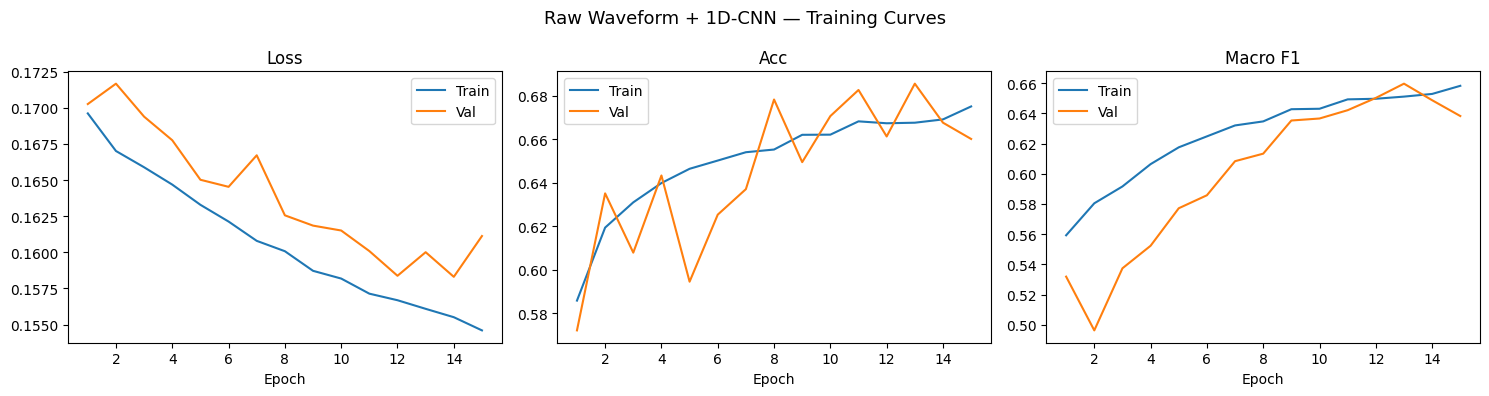

In [13]:
epochs = range(1, actual_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['loss', 'acc', 'macro_f1']):
    ax.plot(epochs, history[f'train_{metric}'], label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   label='Val')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.legend()
plt.suptitle('Raw Waveform + 1D-CNN \u2014 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation

### 7.1 Overall test metrics and confusion matrix

Loads the best-by-val-F1 checkpoint and reports:
- **Loss (focal)** — matches the training objective
- **Loss (unweighted CE)** — the standard cross-entropy form, easier to interpret without knowing the focal-loss α weights
- **Accuracy** — overall fraction correct
- **Macro F1** — unweighted average of per-class F1 (treats apnea and non-apnea equally regardless of frequency)

The confusion matrix breaks down which class confusions dominate the errors.

In [14]:
ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_acc, test_f1 = validate_one_epoch(model, test_loader, criterion, device)
test_loss_unweighted, _, _ = validate_one_epoch(model, test_loader, nn.CrossEntropyLoss(), device)

print('=== Test Results ===')
print(f'Loss (focal, training objective): {test_loss:.4f}')
print(f'Loss (unweighted CE)            : {test_loss_unweighted:.4f}')
print(f'Accuracy                        : {test_acc:.4f}')
print(f'Macro F1                        : {test_f1:.4f}')

=== Test Results ===
Loss (focal, training objective): 0.1615
Loss (unweighted CE)            : 0.6613
Accuracy                        : 0.6662
Macro F1                        : 0.6288


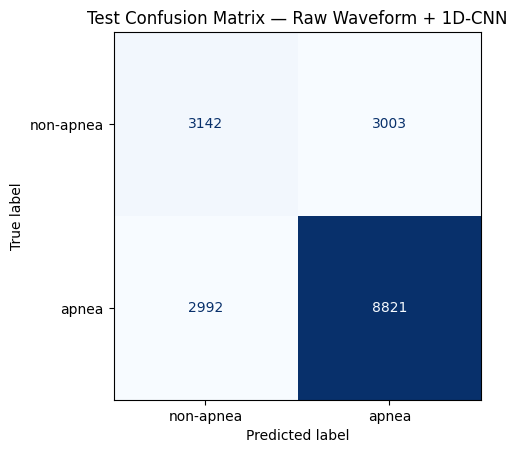

              precision    recall  f1-score   support

   non-apnea       0.51      0.51      0.51      6145
       apnea       0.75      0.75      0.75     11813

    accuracy                           0.67     17958
   macro avg       0.63      0.63      0.63     17958
weighted avg       0.67      0.67      0.67     17958



In [15]:
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Test Confusion Matrix \u2014 Raw Waveform + 1D-CNN")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 7.2 Per apnea-type recall

Evaluates only on apnea segments, broken down by clinical type (OSA / CSA / Mixed-Hypopnea / Other). Useful for spotting which apnea patterns the raw-waveform model handles well versus which it under-detects.

In [16]:
ap_test_df = test_df[test_df['label'] == 1].copy()
ap_dataset = RawWaveformDataset(ap_test_df, PSG_DIR)
ap_loader  = DataLoader(ap_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

preds_all, types_all = [], ap_test_df['apnea_type'].tolist()
with torch.no_grad():
    for inputs, _ in ap_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        preds_all.extend(preds.cpu().numpy())

print('=== Per Apnea-Type Recall (correctly detected as apnea) ===')
for t, name in APNEA_TYPE_NAMES.items():
    if t == 0:
        continue
    idxs = [i for i, tp in enumerate(types_all) if tp == t]
    if not idxs:
        continue
    correct = sum(preds_all[i] == 1 for i in idxs)
    print(f'  Type {t} ({name}): {correct}/{len(idxs)} = {correct/len(idxs):.3f}')

=== Per Apnea-Type Recall (correctly detected as apnea) ===
  Type 1 (OSA): 988/1861 = 0.531
  Type 2 (CSA): 1760/2021 = 0.871
  Type 3 (Mixed/Hypopnea): 5843/7649 = 0.764
  Type 4 (Other): 230/282 = 0.816


## 8. Save results

In [17]:
results = {
    'experiment'      : 'waveform_1dcnn',
    'feature'         : 'raw_waveform',
    'model'           : 'RawWaveform1DCNN (from scratch)',
    'best_epoch'      : best_epoch,
    'best_val_acc'    : float(best_val_acc),
    'best_val_macro_f1': float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_loss_unweighted': float(test_loss_unweighted),
    'test_accuracy'   : float(test_acc),
    'test_macro_f1'   : float(test_f1),
    'classification_report': report,
    'config': {
        'sample_rate'  : SAMPLE_RATE,
        'segment_len'  : SEGMENT_LEN,
        'batch_size'   : BATCH_SIZE,
        'num_epochs'   : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay' : WEIGHT_DECAY,
        'dropout'      : DROPOUT,
        'loss'         : {'type': 'focal', 'gamma': FOCAL_GAMMA, 'alpha': class_weights.tolist()},
        'num_train'    : len(train_dataset),
        'num_val'      : len(val_dataset),
        'num_test'     : len(test_dataset),
    }
}

with open(RESULTS_DIR / 'waveform_1dcnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(RESULTS_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Results saved to:', RESULTS_DIR)

Results saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\waveform_1dcnn\results


## 9. Findings

### Headline metrics

| Metric | Value |
|---|---|
| Test accuracy | **0.6662** |
| Test macro F1 | **0.6288** |
| Test loss (unweighted CE) | 0.6613 |
| Best val macro F1 | 0.6597 (epoch 13 of 15) |
| Best val accuracy | 0.6857 |

### Per apnea-type recall (test set, apnea segments only)

| Apnea sub-type | Recall | Test segments |
|---|---|---|
| Type 1 — OSA (Obstructive Sleep Apnea) | **0.531** | 1,861 |
| Type 2 — CSA (Central Sleep Apnea) | **0.871** | 2,021 |
| Type 3 — Mixed / Hypopnea | **0.764** | 7,649 |
| Type 4 — Other | **0.816** | 282 |

### Discussion

**The model learned, but slowly and to a limited ceiling.** Val F1 climbed steadily from 0.53 (epoch 1) to 0.66 (epoch 13), with train F1 tracking val F1 closely throughout (final gap: train 0.66 vs val 0.64). No clear overfitting — train and val curves stayed parallel. The plateau is more likely a *capacity* limit than an optimization failure: a 64k-parameter from-scratch CNN has limited expressive power for distinguishing subtle breathing patterns from raw 160,000-sample waveforms.

**OSA is the hardest class.** OSA recall (0.531) is far below CSA (0.871), Mixed/Hypopnea (0.764), and Other (0.816). This makes intuitive sense: OSA episodes feature *partial* airway obstruction with continued breathing effort — the audio difference from normal breathing is subtle (snoring, restricted airflow). CSA episodes are acoustically much more distinctive: the patient stops breathing entirely, producing near-silence that's easy for any model to flag as anomalous.

**Class imbalance handling worked.** The focal loss + α-weighted recipe kept the test accuracy (0.666) above the trivial "always predict apnea" baseline (0.658), confirming the model isn't just collapsing to the majority class. However the macro F1 of 0.63 indicates non-apnea recall is also imperfect — the model is genuinely classifying both classes, just imperfectly.

**Loss vs metric divergence.** The unweighted CE loss (0.66) is high relative to the macro F1 (0.63), suggesting the model's probability calibration is loose — it's frequently uncertain even when correct. A larger model or a calibration step (temperature scaling) could tighten this.

### Limitations

- **No pretraining** — trained from scratch with no inductive bias for audio structure. Hand-designed features (mel spectrograms, MFCCs) or audio-pretrained backbones would likely do better on the same data.
- **Tiny model** — 64k parameters is deliberately small. A deeper 1D CNN (1M+ params) trained on the same raw waveforms would probably push these numbers higher, at the cost of more compute.
- **Fixed 10-second window** — real apnea events span 10–30+ seconds. A 10-second segment may catch only the middle of an event, missing the lead-up breathing changes or the recovery breath that follows.
- **Single channel** — no spatial / multi-microphone cues even though some PSG setups capture multiple channels.

### What this experiment establishes

A small CNN learning directly from raw PSG audio reaches **F1 ≈ 0.63** on a held-out subject-stratified test set. This is well above chance and well above always-predict-majority, confirming there's learnable signal in the time-domain waveform without any feature engineering — but the model has clearly not reached the ceiling of what's possible with this dataset. Hand-designed features, larger models, or audio-pretrained backbones are reasonable next directions.